<a href="https://colab.research.google.com/github/bernardarthur0123-netizen/foundation-/blob/main/ML_ENAE(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Import packages
import pandas as pd

    #to use df

import numpy as np

    #for numerical calculations

import matplotlib.pyplot as plt

    #to generate graphs

%matplotlib inline

    #to better adjust figures to the notebook

import seaborn as sns

    #for descriptive graphs

from sklearn.model_selection import train_test_split

    #to separate the train+test sample

from sklearn.linear_model import LogisticRegression

    #for the logistic regression model

from sklearn.metrics import classification_report

    #to evaluate the logistic regression

from sklearn.metrics import confusion_matrix

    #to evaluate logistic regression

from sklearn.metrics import roc_curve,auc

    #to calculate the ROC curve and metric

from sklearn.model_selection import train_test_split, GridSearchCV

    #train_test_split divides the dataset into training data and test data. GridSearchCV finds the best model parameters automatically.

In [152]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve

from sklearn.model_selection import train_test_split, GridSearchCV


Load data
The data is loaded from a CSV file, ‘titanic_train’. Remember to place it in the working directory.

This file contains information about the passengers on the Titanic: whether they survived or not (our variables  and ) and personal information about the passengers.

This file is available on Kaggle: https://www.kaggle.com/c/titanic

In [153]:
#help(pd.read_csv)

In [154]:
#I STORE THE INFORMATION IN THE VARIABLE TITANIC
titanic = pd.read_csv('titanic.csv')
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [155]:
#We set the PassengerId column as indexes, since they are the passenger identifiers
titanic.set_index('PassengerId',inplace=True)
titanic.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Descripción y visualización de los datos

In [156]:
##Variable names
titanic.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [157]:
#Descriptions of numerical variables
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


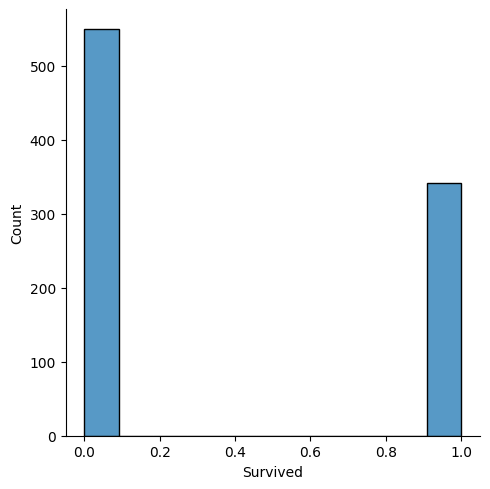

In [158]:
#Distribution of the Survived variable
sns.displot(titanic['Survived'])
plt.show()

In [159]:
#Correlation of numerical variables, to see if there are two independent variables that are highly correlated
titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,-0.549500,0.096067,0.159651,0.216225,1.000000


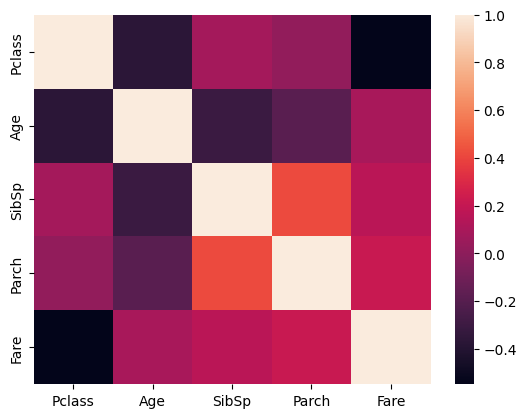

In [160]:
#Correlation map of variables
sns.heatmap(titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr())
plt.show()

We examine whether there are any missing values.

In [161]:
titanic.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [162]:
titanic.isnull().sum()/titanic.shape[0]

,0
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,0.771044


20% of the Age variable and 77% of the Cabin variable are missing. For Age, the mean was 29.7 and the median was 28;

for Cabin, we may have too many missing values, so we will disregard this variable.

In the case of Embarked, we could replace it with the most frequently occurring class, ‘S’, but since there are only two observations, we will eliminate them.

<Axes: >

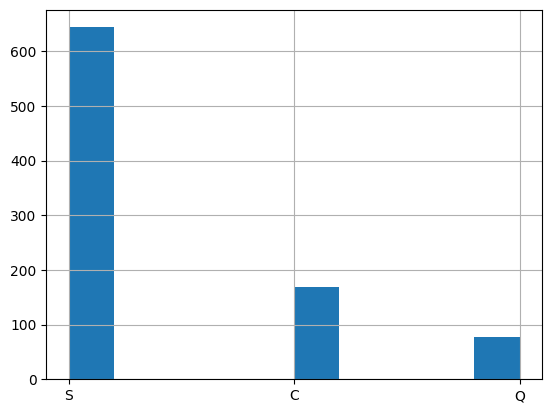

In [163]:
titanic['Embarked'].hist()

Instead of replacing the missing values in Age with 29.7, we see if we can make a more detailed imputation by cross-referencing with another categorical variable, such as Pclass.

<Figure size 2000x1000 with 0 Axes>

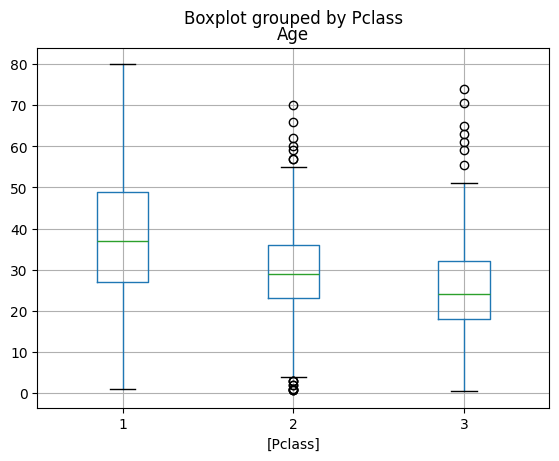

In [164]:
plt.figure(figsize=(20, 10))
titanic[['Age','Pclass']].boxplot(by='Pclass')
plt.show()

We replace the variable Age with 38, 29, or 24 depending on whether Pclass takes the value 1, 2, or 3. To do this, we use a small function.

In [167]:
def imputar_edad(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 38
        elif Pclass == 2:
            return 29
        else:
            return 24

    else:
        return Age

In [168]:
titanic['Age'] = titanic[['Age','Pclass']].apply(imputar_edad,axis=1)

/tmp/ipython-input-2996076498.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/tmp/ipython-input-2996076498.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


In [169]:
titanic.isnull().sum()/titanic.shape[0]

,0
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,0.771044


Now there are no missing values in Age.

We removed the Cabin variable and the two missing records from the Embarked variable.


In [170]:
titanic.drop('Cabin',axis=1,inplace=True)
titanic.dropna(inplace=True)

In [171]:
titanic.isnull().sum()/titanic.shape[0]

,0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0
Embarked,0.0


#### Transformation of categorical variables

It is necessary to transform categorical variables into numerical variables (some models will be able to use categorical variables directly). To do this, we will generate dummy variables that indicate which categorical value of these variables they take.

In [172]:
sex = pd.get_dummies(titanic['Sex'],drop_first=True)
embarked = pd.get_dummies(titanic['Embarked'],drop_first=True)

In [173]:
sex

,male
PassengerId,
1,True
2,False
3,False
4,False
5,True
...,...
887,True
888,False
889,False


In [174]:
embarked

,Q,S
PassengerId,,
1,False,True
2,False,False
3,False,True
4,False,True
5,False,True
...,...,...
887,False,True
888,False,True
889,False,True


As they are Boolean variables, we transform them into binary variables.

In [175]:
sex.male=sex.male*1
sex.male

,male
PassengerId,
1,1
2,0
3,0
4,0
5,1
...,...
887,1
888,0
889,0


In [176]:
embarked.Q=embarked.Q*1
embarked.S=embarked.S*1
embarked

,Q,S
PassengerId,,
1,0,1
2,0,0
3,0,1
4,0,1
5,0,1
...,...,...
887,0,1
888,0,1
889,0,1


We also removed the ticket variable because it is a unique identifier for passengers.

<Axes: >

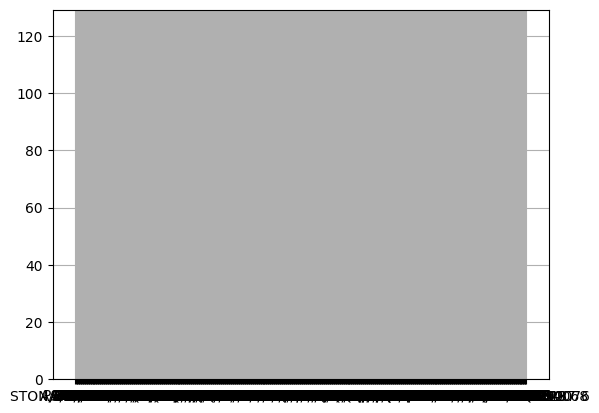

In [177]:
titanic['Ticket'].hist()

In [178]:
titanic.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)
titanic = pd.concat([titanic,sex,embarked],axis=1)
titanic.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
PassengerId,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,0,1
2,1,1,38.0,1,0,71.2833,0,0,0
3,1,3,26.0,0,0,7.9250,0,0,1
4,1,1,35.0,1,0,53.1000,0,0,1
5,0,3,35.0,0,0,8.0500,1,0,1


We split the dataset

In [179]:
# definir variables
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

# dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123456789
)

In [180]:
#X_train, X_test, y_train, y_test = train_test_split(titanic.drop('Survived',axis=1),
    #                                                titanic['Survived'], test_size=0.30,
    #                                                random_state=123456789)

In [181]:
X_train

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
PassengerId,,,,,,,,
793,3,24.0,8,2,69.5500,0,0,1
878,3,19.0,0,0,7.8958,1,0,1
746,1,70.0,1,1,71.0000,1,0,1
540,1,22.0,0,2,49.5000,0,0,0
289,2,42.0,0,0,13.0000,1,0,1
...,...,...,...,...,...,...,...,...
799,3,30.0,0,0,7.2292,1,0,0
348,3,24.0,1,0,16.1000,0,0,1
308,1,17.0,1,0,108.9000,0,0,0


In [182]:
X_test

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
PassengerId,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1
18,2,29.0,0,0,13.0000,1,0,1
382,3,1.0,0,2,15.7417,0,0,0
462,3,34.0,0,0,8.0500,1,0,1
655,3,18.0,0,0,6.7500,0,1,0
...,...,...,...,...,...,...,...,...
193,3,19.0,1,0,7.8542,0,0,1
835,3,18.0,0,0,8.3000,1,0,1
82,3,29.0,0,0,9.5000,1,0,1


In [183]:
y_train

,Survived
PassengerId,
793,0
878,0
746,0
540,1
289,1
...,...
799,0
348,1
308,1


In [184]:
y_test

,Survived
PassengerId,
93,0
18,1
382,1
462,0
655,0
...,...
193,1
835,0
82,1


logistics Regression


In [185]:
# max_iter=1000 ensures convergence
log_reg_model = LogisticRegression(max_iter=1000, random_state=123)
log_reg_model.fit(X_train, y_train)

print("Trained Logistic Model.")

Trained Logistic Model.


In [186]:
# Prediction
y_pred = log_reg_model.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,target,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,0
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,1
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


In [187]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nReport:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[142  19]
 [ 28  78]]

Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       161
           1       0.80      0.74      0.77       106

    accuracy                           0.82       267
   macro avg       0.82      0.81      0.81       267
weighted avg       0.82      0.82      0.82       267



regression turning

In [188]:
# Define the parameter grid to test
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs']
}

# Configure GridSearchCV
log_reg_tuning = LogisticRegression(max_iter=1000, random_state=123)
grid_search = GridSearchCV(estimator=log_reg_tuning,
                           param_grid=param_grid,
                           cv=5,
                           verbose=0)

# Execute the search
grid_search.fit(X_train, y_train)

# Show the best parameters found
print("\nBest C found:", grid_search.best_params_['C'])


Best C found: 10


In [189]:
# The best model is already trained in .best_estimator_
best_log_reg = grid_search.best_estimator_

# Predict the test set with the tuned model
y_pred_tuned = best_log_reg.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred_tuned
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,target,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,0
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,1
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


In [190]:
print("--- Confusion Matrix of the Tuned Model ---")
print(confusion_matrix(y_test, y_pred_tuned))

print("\n--- Classification Report of the Tuned Model ---")
print(classification_report(y_test, y_pred_tuned))

--- Confusion Matrix of the Tuned Model ---
[[142  19]
 [ 28  78]]

--- Classification Report of the Tuned Model ---
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       161
           1       0.80      0.74      0.77       106

    accuracy                           0.82       267
   macro avg       0.82      0.81      0.81       267
weighted avg       0.82      0.82      0.82       267



DT CLASSIFIER

In [191]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree

In [192]:
# Define the parameter grid to test
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configure GridSearchCV
tree_for_tuning = DecisionTreeClassifier(random_state=123)
grid_search = GridSearchCV(estimator=tree_for_tuning,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=0) # Verbose 0 to not clutter the output

# Execute the search
grid_search.fit(X_train, y_train)

# Show the best parameters found
print("\nBest parameters found:")
print(grid_search.best_params_)


Best parameters found:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [193]:
# The best model is already trained in .best_estimator_
best_log_reg = grid_search.best_estimator_

# Predict the test set with the tuned model
y_pred_tuned = best_log_reg.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred_tuned
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,target,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,1
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,0
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


In [194]:
print("--- Confusion Matrix of the Tuned Model ---")
print(confusion_matrix(y_test, y_pred_tuned))

print("\n--- Classification Report of the Tuned Model ---")
print(classification_report(y_test, y_pred_tuned))

--- Confusion Matrix of the Tuned Model ---
[[146  15]
 [ 41  65]]

--- Classification Report of the Tuned Model ---
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       161
           1       0.81      0.61      0.70       106

    accuracy                           0.79       267
   macro avg       0.80      0.76      0.77       267
weighted avg       0.79      0.79      0.78       267



Random Forest CLASS

In [195]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [196]:
# Define the parameter grid to test
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'max_features': ['sqrt', 'log2']
}

# Configure GridSearchCV
rf_for_tuning = RandomForestClassifier(random_state=123)
grid_search_rf = GridSearchCV(estimator=rf_for_tuning,
                              param_grid=param_grid_rf,
                              cv=5,
                              scoring='accuracy',
                              verbose=0)

# Execute the search
grid_search_rf.fit(X_train, y_train)

# Show the best parameters found
print("\nBest parameters found:")
print(grid_search_rf.best_params_)


Best parameters found:
{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}


In [197]:
# The best model is already trained in .best_estimator_
best_rf = grid_search_rf.best_estimator_

# Predict the test set with the tuned model
y_pred_tuned = best_rf.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['actual_class'] = y_test
df_results['prediction'] = y_pred_tuned
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,actual_class,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,0
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,1
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


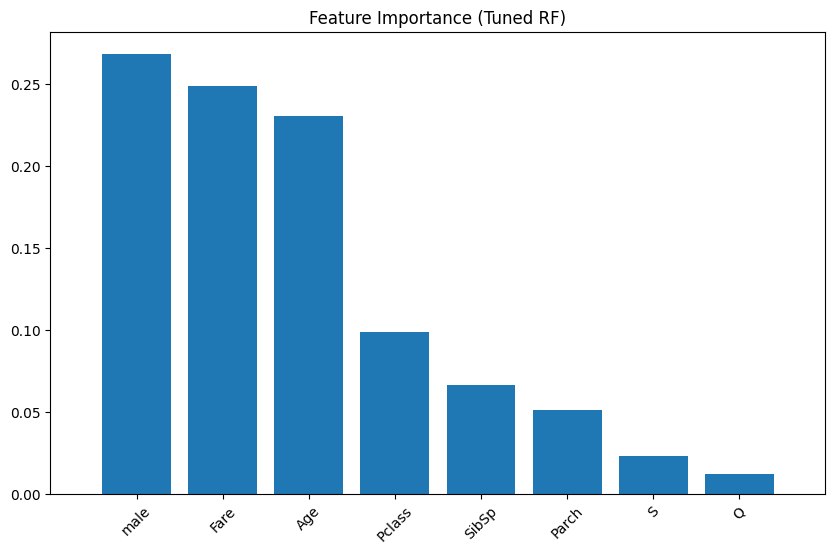

In [198]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Tuned RF)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.show()

BOOSTING

In [199]:
from sklearn.ensemble import GradientBoostingClassifier
# Create the GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=123)

# Train the model
gb_model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [200]:
# Prediction
y_pred = gb_model.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['actual_class'] = y_test
df_results['prediction'] = y_pred
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,actual_class,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,0
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,1
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


In [201]:
# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report (Precision)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[141  20]
 [ 31  75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       161
           1       0.79      0.71      0.75       106

    accuracy                           0.81       267
   macro avg       0.80      0.79      0.80       267
weighted avg       0.81      0.81      0.81       267



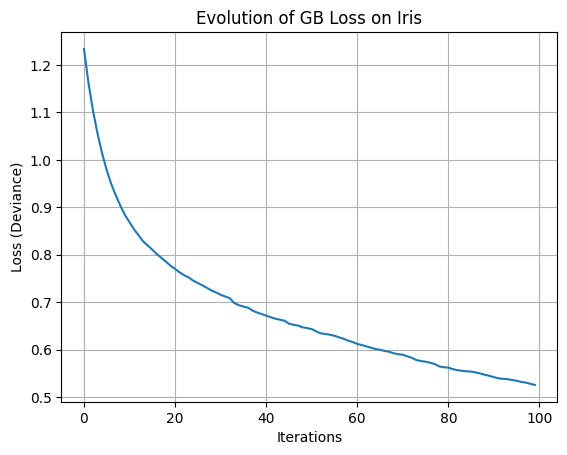

In [203]:
plt.plot(gb_model.train_score_)
plt.title("Evolution of GB Loss on Iris")
plt.xlabel("Iterations")
plt.ylabel("Loss (Deviance)")
plt.grid(True)
plt.show()

In [205]:
print("--- Confusion Matrix of the Tuned GB ---")
print(confusion_matrix(y_test, y_pred_tuned))

print("\n--- Classification Report of the Tuned GB ---")
print(classification_report(y_test, y_pred_tuned))

--- Confusion Matrix of the Tuned GB ---
[[143  18]
 [ 27  79]]

--- Classification Report of the Tuned GB ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       161
           1       0.81      0.75      0.78       106

    accuracy                           0.83       267
   macro avg       0.83      0.82      0.82       267
weighted avg       0.83      0.83      0.83       267



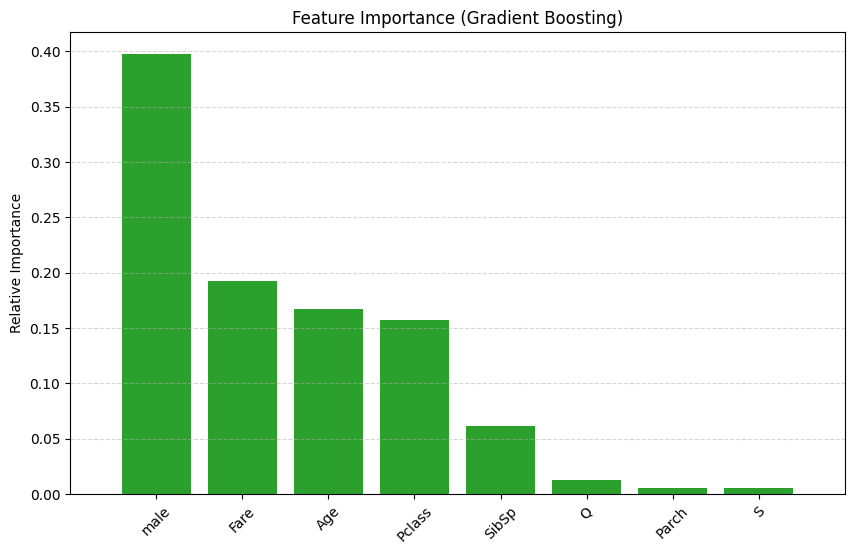

In [207]:
# Extract feature importances
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Gradient Boosting)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='#2ca02c') # Green
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel("Relative Importance")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Navies Bayes

In [209]:
from sklearn.naive_bayes import GaussianNB
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
print("Naive Bayes Model trained.")

Naive Bayes Model trained.


In [210]:
# Grid Search
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=20)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid, cv=5)
grid_nb.fit(X_train, y_train)

print(f"Best smoothing: {grid_nb.best_params_['var_smoothing']:.2e}")

Best smoothing: 6.95e-07


In [211]:
# Prediction
y_pred = model_nb.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,target,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,0
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,1
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


In [212]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nReport:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[130  31]
 [ 31  75]]

Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       161
           1       0.71      0.71      0.71       106

    accuracy                           0.77       267
   macro avg       0.76      0.76      0.76       267
weighted avg       0.77      0.77      0.77       267



In [223]:
# Extract learned means
class_names = ['Not Survived', 'Survived']

df_means = pd.DataFrame(grid_nb.best_estimator_.theta_,
                         columns=X_train.columns,
                         index=class_names)

print("Learned Means (Centroids of the distributions):")
print(df_means.round(2))

Learned Means (Centroids of the distributions):
              Pclass    Age  SibSp  Parch  Fare  male     Q     S
Not Survived    2.54  29.55   0.55   0.35  22.3  0.85  0.07  0.78
Survived        1.94  28.09   0.44   0.46  48.8  0.34  0.08  0.66


KK NEIGHNEIGHBORS

In [229]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


In [230]:
# Data scaling
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualize first rows of scaled data
df_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
print("\n--- First 5 rows of SCALED TRAINING data ---")
df_train_scaled.head()


--- First 5 rows of SCALED TRAINING data ---


,Pclass,Age,SibSp,Parch,Fare,male,Q,S
PassengerId,,,,,,,,
793,0.823868,-0.385016,6.859173,1.910904,0.717177,-1.380776,-0.285901,0.600875
878,0.823868,-0.769887,-0.468273,-0.466261,-0.468810,0.724230,-0.285901,0.600875
746,-1.576348,3.155800,0.447658,0.722322,0.745070,0.724230,-0.285901,0.600875
540,-1.576348,-0.538965,-0.468273,1.910904,0.331493,-1.380776,-0.285901,-1.664241
289,-0.376240,1.000521,-0.468273,-0.466261,-0.370625,0.724230,-0.285901,0.600875


In [231]:
# K=5 is the default value
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


In [232]:
# Prediction
y_pred = model_knn.predict(X_test_scaled)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,target,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,1
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,1
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


In [233]:
# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report (Precision)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[140  21]
 [ 32  74]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       161
           1       0.78      0.70      0.74       106

    accuracy                           0.80       267
   macro avg       0.80      0.78      0.79       267
weighted avg       0.80      0.80      0.80       267



In [234]:
# Take the first test sample
sample = [X_test_scaled[0]]
prediction = model_knn.predict(sample)
neighbors_idx = model_knn.kneighbors(sample, n_neighbors=3, return_distance=False)

print(f"Prediction: {iris.target_names[prediction][0]}")
print(f"Based on similarity with training samples indices: {neighbors_idx[0]}")

Prediction: versicolor
Based on similarity with training samples indices: [525 556 603]


SUPPORT VECTOR MACHINE

In [236]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [237]:
# Data scaling
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualize first rows of scaled data
df_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
print("\n--- First 5 rows of SCALED TRAINING data ---")
df_train_scaled.head()


--- First 5 rows of SCALED TRAINING data ---


,Pclass,Age,SibSp,Parch,Fare,male,Q,S
PassengerId,,,,,,,,
793,0.823868,-0.385016,6.859173,1.910904,0.717177,-1.380776,-0.285901,0.600875
878,0.823868,-0.769887,-0.468273,-0.466261,-0.468810,0.724230,-0.285901,0.600875
746,-1.576348,3.155800,0.447658,0.722322,0.745070,0.724230,-0.285901,0.600875
540,-1.576348,-0.538965,-0.468273,1.910904,0.331493,-1.380776,-0.285901,-1.664241
289,-0.376240,1.000521,-0.468273,-0.466261,-0.370625,0.724230,-0.285901,0.600875


In [238]:
# probability=True allows calculating posterior probabilities
model_svm = SVC(kernel='rbf', probability=True)
model_svm.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


In [239]:
# Prediction
y_pred = model_svm.predict(X_test_scaled)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred
df_results.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S,target,prediction
PassengerId,,,,,,,,,,
93,1,46.0,1,0,61.1750,1,0,1,0,0
18,2,29.0,0,0,13.0000,1,0,1,1,0
382,3,1.0,0,2,15.7417,0,0,0,1,1
462,3,34.0,0,0,8.0500,1,0,1,0,0
655,3,18.0,0,0,6.7500,0,1,0,0,1


In [240]:
# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report (Precision)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[145  16]
 [ 29  77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       161
           1       0.83      0.73      0.77       106

    accuracy                           0.83       267
   macro avg       0.83      0.81      0.82       267
weighted avg       0.83      0.83      0.83       267



In [241]:
n_vec = model_svm.support_vectors_.shape[0]
total = X_train.shape[0]
print(f"Support Vectors used: {n_vec} out of {total} samples ({n_vec/total:.1%}).")
print("Interpretation: The decision boundary depends exclusively on these difficult points.")

Support Vectors used: 293 out of 622 samples (47.1%).
Interpretation: The decision boundary depends exclusively on these difficult points.
